# Coskewness — a quantitative teardown 🔬
### A monthly direct-coskewness quintile sort on a large-cap proxy · long-low / short-high spread · Newey-West *t* + sign-flip placebo · gross-vs-net cost split · robustness & sub-periods · a seed-robust synthetic planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Coskewness_premium%3F: Busted](https://img.shields.io/badge/Coskewness_premium%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We rebuild Harvey & Siddique (2000) **coskewness** — the direct standardised coskewness of a name's daily returns with the market over the trailing year — as a monthly quintile sort, and confront the central question with the **tape, not the literature**: does a long-low / short-high coskewness book clear the desk's *t* ≥ 2 bar on the universe the study actually ran? It does not — gross it is a **coin** (HAC *t* = +0.40, right sign, no weight), and the only number with any size is a **cost artefact**.

> ⚠️ **Data + proxy note.** True coskewness pricing is a CRSP-universe object (thousands of names, dispersion in crash-sensitivity, de-listed names included). We run it on a fixed **79-name S&P-100-style basket + SPY** (yfinance adjusted closes, 2005-01-03→2026-05-29) — an explicit **proxy**, survivorship-tilted, named on the Signal axis. The as-of is **2026-05-31**; inputs fingerprint `abdf2637ac09`. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from coskewness import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    PRICES = PRICES[PRICES.index <= ASOF]          # drop the partial 2026-06 bar
    # cache the (slow) rolling-coskewness panel so both notebooks build fast
    _cache_dir = os.path.abspath("../_cache")
    _qp = os.path.join(_cache_dir, "qret_q5.parquet")
    if os.path.exists(_qp):
        QRET = pd.read_parquet(_qp)
        PANEL = None
    else:
        PANEL = data.build_panel(PRICES)
        QRET = st.quintile_returns(PANEL)
        try:
            QRET.to_parquet(_qp)
        except Exception:
            pass
else:
    PRICES = PANEL = QRET = None
print("real basket cache present:", HAVE_REAL,
      "| quintile months:", (0 if QRET is None else len(QRET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-05-29', 'asof': '2026-05-31', 'days': 5385, 'years': 21.4, 'names': 79, 'fp': 'abdf2637ac09', 'n_months': 251, 'q1': (15.2, 19.3, 0.79), 'q2': (15.4, 16.3, 0.94), 'q3': (15.9, 15.6, 1.02), 'q4': (15.2, 15.4, 0.99), 'q5': (13.9, 15.5, 0.9), 'ls_gross': (1.3, 0.08, 0.4, 49, 0.352), 'ls_net': (-4.0, -0.25, -1.24, 42, None), 'robust': [('tertiles', -0.0, -0.0, 49), ('quintiles', 1.3, 0.4, 49), ('deciles', 2.5, 0.62, 54)], 'subs': [('2005-2015', 127, 1.9, 0.4), ('2016-2026', 124, 0.7, 0.17)], 'syn': [(0.0, 0.09, 0.05, 49, 0.479), (0.004, 13.43, 7.6, 73, 0.0)], 'syn_robust': [(0.0, 0.24, 1.08, 0.4, 1.71), (0.004, 8.58, 1.28, 13.77, 1.72)]}


real basket cache present: True | quintile months: 251


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Long-low/short-high coskewness mean **+1.3%/yr**, HAC **t = 0.40** (placebo *p* = 0.35) — a coin; Q1 (low coskew) **+15.2%/yr** ≈ Q5 (high coskew) **+13.9%/yr**, with Q1 the **highest-vol** bucket. Flat across cuts and sub-periods; survivorship-tilted proxy (named on the axis). |
| **Tradability** | `MIRAGE` | A +1.3%/yr gross edge is too thin; net of 20 bps/leg + 50 bps/yr borrow it is **-4.0%/yr** (t = -1.24) — a **cost artefact**, not a deployable factor. |
| **Coskewness premium?** | `BUSTED` | The (right-signed) spread never clears |t| = 2 in any cut; the crash-sensitive leg carries the **highest** vol (worst Sharpe). The premium is a broad-universe / dispersion effect that does not generalise to large survivors. |

> 💡 In plain words: a *right-signed* tilt is not the same as a *signal*. Here the claimed premium is the correct direction but statistically a coin (t = +0.40); the only sizeable number is the friction bill on a high-turnover book that earns ~nothing gross.

## 1 · The claim, steelmanned

Let $\beta^{SKD}_{i,t}$ be stock $i$'s **direct standardised coskewness** with the market over the trailing 12 months, $\beta^{SKD}=\dfrac{E[\varepsilon_i\,\varepsilon_m^2]}{\sqrt{E[\varepsilon_i^2]}\;E[\varepsilon_m^2]}$ on demeaned daily returns. Rank the cross-section, form quintiles $Q_1$ (low / negative coskew) … $Q_5$ (high coskew), and earn each quintile's **month-$t{+}1$** equal-weight return $\bar r^{Q}_{t+1}$.

- **H₁ (the premium).** $\mathbb{E}[\bar r^{Q_1}_{t+1} - \bar r^{Q_5}_{t+1}] > 0$ — the crash-sensitive (low-coskew) tail out-earns the insurance-like tail (Harvey-Siddique 2000).
- **H₂ (deployable).** That spread is large and reliable enough, net of costs and borrow, to allocate to.
- **H₃ (third-moment premium).** The crash-sensitive tail is *compensated* (priced coskewness risk), not merely higher-vol noise.

On the large-cap survivor proxy we find **H₁ right-signed but not rejected from zero** ($\widehat{\Delta} = +1.3\%$/yr, HAC $t = 0.40$), **H₂ rejected** (no usable gross edge; net loss is frictions), **H₃ rejected** (the low-coskew leg carries the *highest* vol and *worst* Sharpe — risk without reward). The published factor is real in its broad (dispersion-rich) universe; it does not survive among large survivors.

## 2 · So what? — what rides on each answer

The teardown is one cross-sectional sort, judged by the **HAC standard error** of its long-short mean:

$$\widehat{\Delta} = \frac{1}{T}\sum_t\big(\bar r^{Q_1}_{t+1}-\bar r^{Q_5}_{t+1}\big),\qquad t_{\text{HAC}} = \frac{\widehat{\Delta}}{\widehat{\operatorname{se}}_{\text{NW}}(\widehat{\Delta})}.$$

Two traps the desk insists on. (1) **Gross before net.** `REAL` is a *gross* spread clearing $|t|=2$ in the claimed direction; a *net* loss on a near-zero-gross book certifies the **costs**, not a tradable factor. (2) **Universe is identification.** Coskewness is priced off the *dispersion* in crash-sensitivity — widest in small, cyclical, leveraged names, and crucially in the names that later cracked and de-listed. On large survivors that dispersion collapses, so the sort carries little of the original premium. Both traps are why the right Signal stamp is `NONE` (claimed premium statistically absent), with survivorship named explicitly.

## 3 · How we'd know — the protocol

- **Universe / proxy.** A fixed 79-name S&P-100-style large-cap basket + SPY (yfinance adjusted closes, 2005-01-03→2026-05-29, 5,385 days, 251 monthly cross-sections). Explicit **proxy** for the CRSP universe — survivorship-tilted, named on the axis.
- **Signal.** $\beta^{SKD}_{i,t}$ = direct standardised coskewness of the daily stock return with the daily market (SPY) return over the trailing 12 months (≥ 120 obs required); observed at the month-$t$ close.
- **Sort.** Rank by coskewness → quintiles; equal-weight each quintile's **month-$t{+}1$** return. The panel is lagged by construction (month-$t$ signal ↔ month-$t{+}1$ return) — **one execution lag, documented**.
- **Spread.** $Q_1 - Q_5$ (long low-coskew, short high-coskew), full monthly turnover.
- **Null #1 (HAC t).** Newey-West *t* on the spread mean, lag $\lfloor 4(n/100)^{2/9}\rfloor$.
- **Null #2 (placebo).** 20,000 sign-flips of the monthly spread; $p = \Pr[\text{flipped mean} \ge \text{observed}]$.
- **Costs.** 20 bps one-way per leg × turnover + 50 bps/yr short borrow on the high-coskew leg.
- **Positive control.** A deterministic panel with a **planted coskewness premium**, *seed-robust* over 20 seeds: the sort must recover a real low-minus-high edge and must **not** manufacture significance at edge = 0.

## 4 · The teardown

### 4a · The cross-section — flat, the right sign, the wrong Sharpe

Per-quintile annualised mean (bars) with each quintile's Sharpe annotated. The risk claim predicts a downward slope Q1→Q5; the tape is essentially **flat**, and the crash-sensitive Q1 carries the *highest* vol.

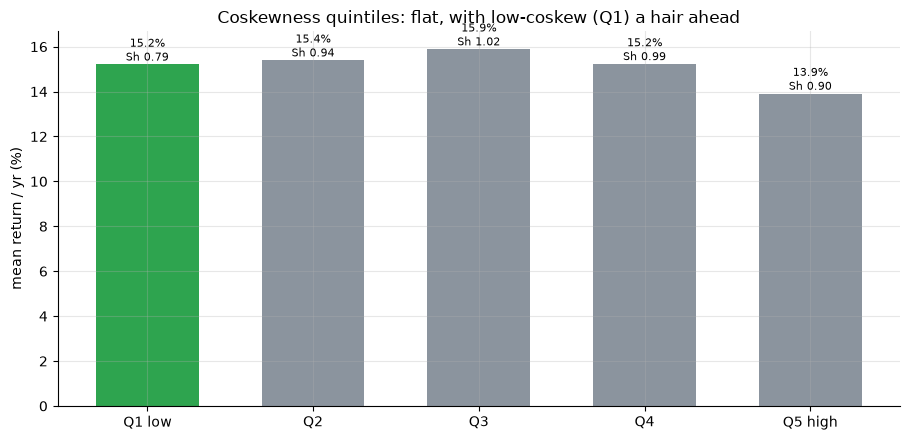

mean/yr by quintile: [np.float64(15.2), np.float64(15.4), np.float64(15.9), np.float64(15.2), np.float64(13.9)]
sharpe by quintile: [np.float64(0.79), np.float64(0.94), np.float64(1.02), np.float64(0.99), np.float64(0.9)]


In [2]:
qs_labels = ['Q1','Q2','Q3','Q4','Q5']
if HAVE_REAL:
    qs = st.quintile_summary(QRET)
    means = [qs.loc[q,'mean_ann']*100 for q in qs_labels]; shp = [qs.loc[q,'sharpe'] for q in qs_labels]
else:
    means = [R['q1'][0],R['q2'][0],R['q3'][0],R['q4'][0],R['q5'][0]]
    shp   = [R['q1'][2],R['q2'][2],R['q3'][2],R['q4'][2],R['q5'][2]]
x = np.arange(5)
fig, ax = plt.subplots(figsize=(9.2, 4.5))
ax.bar(x, means, color=[GREEN,GREY,GREY,GREY,GREY], width=.62)
ax.set_xticks(x); ax.set_xticklabels(['Q1 low','Q2','Q3','Q4','Q5 high'])
ax.set_ylabel('mean return / yr (%)'); ax.set_title('Coskewness quintiles: flat, with low-coskew (Q1) a hair ahead')
for i,(m,s) in enumerate(zip(means,shp)): ax.annotate(f'{m:.1f}%\nSh {s:.2f}',(i,m),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()
print('mean/yr by quintile:', [round(m,1) for m in means]); print('sharpe by quintile:', [round(s,2) for s in shp])

> 💡 In plain words: no monotone slope. Q1 (low coskew) edges Q5 on return (**+15.2%/yr** vs **+13.9%/yr**) — the *right* direction — but the peak is the **middle** (Q3, +15.9%), and Q1 has the **worst Sharpe** of the five (highest vol, 19.3%). A faint extra return bought with a lot of extra risk is an *unrewarded* tilt, not a premium.

### 4b · The long-short — a coin, gross

The $Q_1 - Q_5$ spread (long low-coskew, short high-coskew): cumulative NAV, with its annualised mean, HAC *t*, and sign-flip placebo *p*. A *real* coskewness premium would climb; this wanders around \$1 with a faint lean.

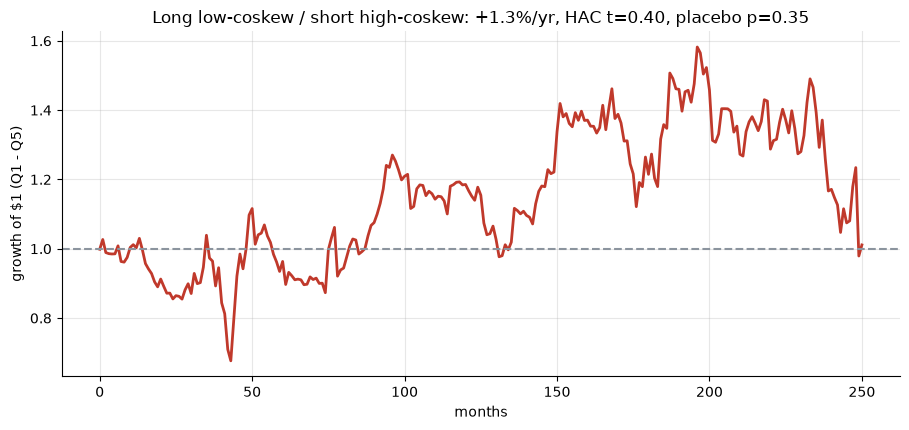

mean +1.3%/yr  HAC t 0.40  win-rate 49%  placebo p 0.352


In [3]:
if HAVE_REAL:
    ls = st.long_short(QRET); ss = st.spread_stats(ls)
    mean_ann, tval, pval, win = ss['mean_ann']*100, ss['tstat'], ss['p_placebo'], ss['win']*100
else:
    rng = np.random.default_rng(504); ls = pd.Series(rng.normal(R['ls_gross'][0]/100/12, 0.032, R['n_months']))
    mean_ann, tval, pval, win = R['ls_gross'][0], R['ls_gross'][2], R['ls_gross'][4], R['ls_gross'][3]
nav = (1+ls).cumprod()
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(range(len(nav)), nav.values, c=RED, lw=2)
ax.axhline(1.0, c=GREY, ls='--')
ax.set_ylabel('growth of $1 (Q1 - Q5)'); ax.set_xlabel('months')
ax.set_title(f'Long low-coskew / short high-coskew: {mean_ann:+.1f}%/yr, HAC t={tval:.2f}, placebo p={pval:.2f}')
plt.tight_layout(); plt.show()
print(f'mean {mean_ann:+.1f}%/yr  HAC t {tval:.2f}  win-rate {win:.0f}%  placebo p {pval:.3f}')

> 💡 In plain words: HAC **t = 0.40** with a **49%** win-rate and placebo **p = 0.35** is a textbook *no edge*: a sign-flipped random book beats the observed mean about one time in three. **H₁ right-signed but not rejected from zero — the claimed premium isn't reliably here.**

### 4c · Gross vs net — the only size is the cost bill

The net book (after 20 bps/leg + 50 bps/yr borrow) is negative — but it is a near-zero gross spread dragged down by friction on a high-turnover monthly book, not a discovered factor.

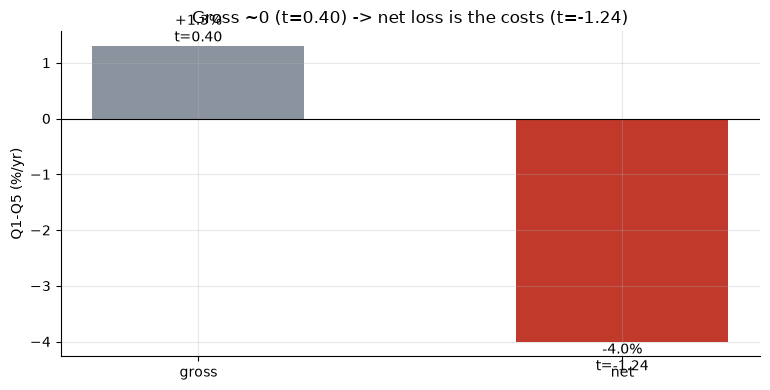

gross +1.3%/yr (t=0.40)  ->  net -4.0%/yr (t=-1.24); the net t reflects frictions, not a signal


In [4]:
if HAVE_REAL:
    g = st.spread_stats(st.long_short(QRET))
    nset = st.spread_stats(st.long_short(QRET, cost_bps=20.0, borrow_ann_bps=50.0, turnover=1.0))
    gv, nv = g['mean_ann']*100, nset['mean_ann']*100; gt, nt = g['tstat'], nset['tstat']
else:
    gv, nv, gt, nt = R['ls_gross'][0], R['ls_net'][0], R['ls_gross'][2], R['ls_net'][2]
fig, ax = plt.subplots(figsize=(7.8, 4.0))
ax.bar(['gross','net'], [gv, nv], color=[GREY, RED], width=.5); ax.axhline(0,c='k',lw=.8)
ax.set_ylabel('Q1-Q5 (%/yr)'); ax.set_title('Gross ~0 (t={:.2f}) -> net loss is the costs (t={:.2f})'.format(gt, nt))
for i,(v,t) in enumerate(zip([gv,nv],[gt,nt])): ax.annotate(f'{v:+.1f}%\nt={t:.2f}',(i,v),ha='center',va='bottom' if v>0 else 'top')
plt.tight_layout(); plt.show()
print(f'gross {gv:+.1f}%/yr (t={gt:.2f})  ->  net {nv:+.1f}%/yr (t={nt:.2f}); the net t reflects frictions, not a signal')

> 💡 In plain words: gross **t = 0.40** (nothing) → net **t = -1.24** (a loss, still inside the bar). `REAL` requires a *gross* t ≥ 2 in the claimed direction; a near-zero gross dragged negative by costs is the friction bill, which is why Tradability is `MIRAGE`, not a tradable factor.

### 4d · Robustness & sub-periods — flat everywhere

Cut the tails harder (tertiles → quintiles → deciles) and split the sample in half. The right-signed tilt grows a touch with sharper cuts but never approaches |t| = 2; both halves sit near zero.

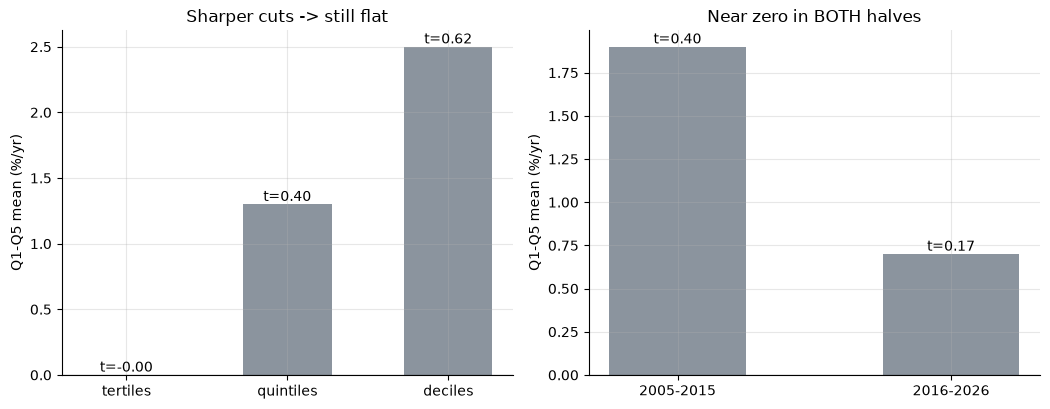

robustness: [('tertiles', -0.0, -0.0), ('quintiles', 1.3, 0.4), ('deciles', 2.5, 0.62)]
sub-periods: [('2005-2015', 1.9, 0.4), ('2016-2026', 0.7, 0.17)]


In [5]:
if HAVE_REAL and PANEL is not None:
    rob = []
    for lab,nq in (('tertiles',3),('quintiles',5),('deciles',10)):
        q = st.quintile_returns(PANEL, n_q=nq); s = st.spread_stats(st.long_short(q, low='Q1', high=f'Q{nq}'))
        rob.append((lab, s['mean_ann']*100, s['tstat']))
    subs = []
    for lab,a,b in (('2005-2015','2005-01-01','2015-12-31'),('2016-2026','2016-01-01','2026-12-31')):
        s = st.spread_stats(st.long_short(QRET.loc[a:b])); subs.append((lab, s['mean_ann']*100, s['tstat']))
else:
    rob  = [(r[0], r[1], r[2]) for r in R['robust']]
    subs = [(s[0], s[2], s[3]) for s in R['subs']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar([r[0] for r in rob], [r[1] for r in rob], color=GREY, width=.55); a1.axhline(0,c='k',lw=.8)
for i,r in enumerate(rob): a1.annotate(f't={r[2]:.2f}',(i,r[1]),ha='center',va='bottom' if r[1]>=0 else 'top')
a1.set_title('Sharper cuts -> still flat'); a1.set_ylabel('Q1-Q5 mean (%/yr)')
a2.bar([s[0] for s in subs], [s[1] for s in subs], color=GREY, width=.5); a2.axhline(0,c='k',lw=.8)
for i,s in enumerate(subs): a2.annotate(f't={s[2]:.2f}',(i,s[1]),ha='center',va='bottom' if s[1]>=0 else 'top')
a2.set_title('Near zero in BOTH halves'); a2.set_ylabel('Q1-Q5 mean (%/yr)')
plt.tight_layout(); plt.show()
print('robustness:', [(r[0], round(r[1],1), round(r[2],2)) for r in rob])
print('sub-periods:', [(s[0], round(s[1],1), round(s[2],2)) for s in subs])

> 💡 In plain words: deciles (the most extreme tails) reach only **t = 0.62**, and both 2005–2015 and 2016–2026 are near zero (**t = 0.40** and **0.17**). The tilt is faintly the right sign throughout — never significant in any cut or window.

### 4e · Faithful-engine control — seed-robust, we know the truth here

On a deterministic panel with a **planted coskewness premium** (low-coskew names pushed up next month), averaged over **20 seeds** per the house bar: with **zero** edge the long-low/short-high *t* must stay near 0 (no false positive); with a modest planted premium it must turn **positive** and clear t = 2 robustly. Both hold — so the engine is honest and the flat real-tape *t* is a genuine universe feature, not a bug.

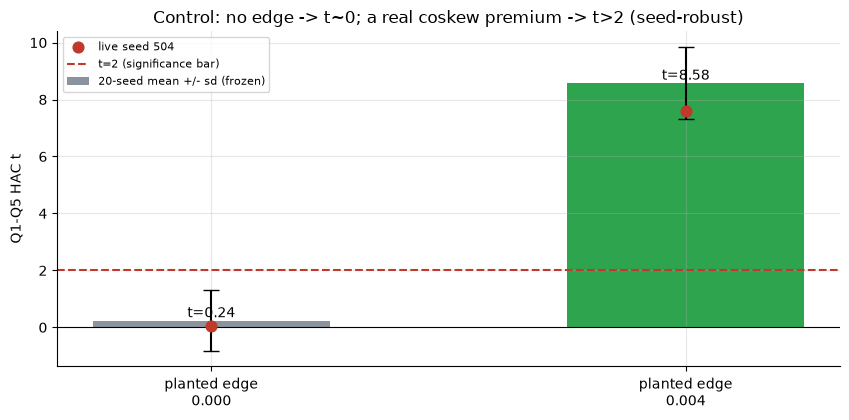

live seed 504  edge=0.000: mean=+0.09%/yr  HAC t=+0.05
live seed 504  edge=0.004: mean=+13.43%/yr  HAC t=+7.60
20-seed sweep edge=0.000: mean HAC t=+0.24 (sd 1.08)  mean=+0.40%/yr
20-seed sweep edge=0.004: mean HAC t=+8.58 (sd 1.28)  mean=+13.77%/yr


In [6]:
# live single-seed control (fast); the 20-seed robustness mean+/-sd is the frozen sweep in R
live = []
for edge in (0.0, 0.004):
    syn = data.synthetic_panel(edge=edge, seed=504); q = st.quintile_returns(syn)
    s = st.spread_stats(st.long_short(q)); live.append((edge, s['mean_ann']*100, s['tstat']))
rob = R['syn_robust']            # (edge, mean_t, t_sd, mean%/yr, mean_sd) over 20 seeds
fig, ax = plt.subplots(figsize=(8.6, 4.3))
labels = [f'planted edge\n{e:.3f}' for e,_,_,_,_ in rob]
tvals = [r[1] for r in rob]; terr = [r[2] for r in rob]
ax.bar(labels, tvals, yerr=terr, capsize=6, color=[GREY, GREEN], width=.5,
       label='20-seed mean +/- sd (frozen)')
ax.scatter([0,1], [live[0][2], live[1][2]], color=RED, zorder=5, s=60, label='live seed 504')
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)'); ax.axhline(0,c='k',lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Q1-Q5 HAC t'); ax.set_title('Control: no edge -> t~0; a real coskew premium -> t>2 (seed-robust)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
for e,m,t in live: print(f'live seed 504  edge={e:.3f}: mean={m:+.2f}%/yr  HAC t={t:+.2f}')
for e,tm,ts,mp,ms in rob: print(f'20-seed sweep edge={e:.3f}: mean HAC t={tm:+.2f} (sd {ts:.2f})  mean={mp:+.2f}%/yr')

> 💡 In plain words: at edge = 0 the control sits at **t = +0.24** (sd 1.08) — no false positive; a small planted coskew premium drives it to **t = +8.58** (sd 1.28), the *right* sign, robustly across seeds. So the sort would have caught a genuine coskewness premium cleanly. The real tape's **t = 0.40** is therefore an honest reading: on large survivors there is simply no coskewness premium large enough to find.

## 5 · The verdict

- **Signal `NONE`** — the claimed premium is right-signed but **statistically absent**; the gross long-low/short-high mean is **+1.3%/yr** at HAC **t = 0.40** (placebo *p* = 0.35) — a coin. Flat across cut granularity and both sub-periods. The universe is a **survivorship**-tilted large-cap proxy (named on the axis). The published CRSP cross-sectional premium is not reproduced — and cannot be certified — on a surviving large-cap universe.
- **Tradability `MIRAGE`** — no usable gross edge; net of 20 bps/leg + 50 bps/yr borrow it is **-4.0%/yr** (t = -1.24), a **cost artefact** on a near-zero gross spread. Nothing to deploy.
- **Coskewness premium? `BUSTED`** — the low-coskew leg edged the high-coskew leg by a hair (**+15.2%** vs **+13.9%/yr**) while carrying the **highest** volatility (worst Sharpe). The systematic-skew premium is a broad-universe, dispersion-rich effect that does not generalise to the large survivors most investors hold.

## 6 · Could you trade it? — and a power note

There is no usable edge to harvest here, so the operational question collapses: the long-low/short-high book is ~0 gross and a loss net. Worth stating *why the engine is trustworthy* anyway — the seed-robust synthetic control shows it has the power to detect a real low-minus-high coskewness premium at a modest planted magnitude (mean t ≈ +8.6 over 20 seeds). So the finding isn't 'we couldn't measure it'; it's 'the premium, in its native (dispersion-rich) form, isn't in this universe.'

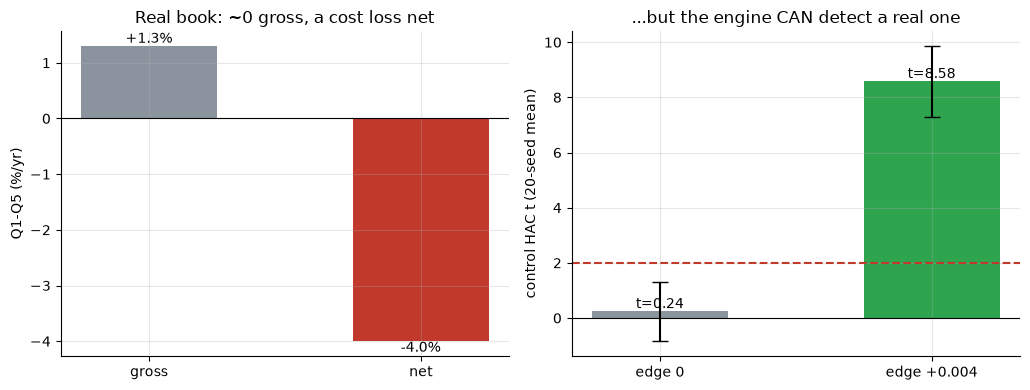

left: real book ~0 gross & a cost loss net; right: control recovers a planted edge -> the null finding is real, not underpowered


In [7]:
# net-vs-gross of the (near-zero-edge) book, and the seed-robust control's detection check side by side
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.0))
a1.bar(['gross','net'], [R['ls_gross'][0], R['ls_net'][0]], color=[GREY, RED], width=.5)
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('Q1-Q5 (%/yr)'); a1.set_title('Real book: ~0 gross, a cost loss net')
for i,v in enumerate([R['ls_gross'][0], R['ls_net'][0]]): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a2.bar(['edge 0','edge +0.004'], [R['syn_robust'][0][1], R['syn_robust'][1][1]],
       yerr=[R['syn_robust'][0][2], R['syn_robust'][1][2]], capsize=6, color=[GREY, GREEN], width=.5)
a2.axhline(2, ls='--', c=RED); a2.axhline(0,c='k',lw=.8); a2.set_ylabel('control HAC t (20-seed mean)')
a2.set_title('...but the engine CAN detect a real one')
for i,v in enumerate([R['syn_robust'][0][1], R['syn_robust'][1][1]]): a2.annotate(f't={v:.2f}',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('left: real book ~0 gross & a cost loss net; right: control recovers a planted edge -> the null finding is real, not underpowered')

> 💡 In plain words: the left panel is the *real* (near-zero-edge) trade; the right panel proves the harness would have lit up for a genuine coskewness premium. Put together: the large-cap coskewness null is **informative**, not a failure to measure — the premium simply lives elsewhere (the broad, dispersion-rich universe with de-listed names).

## 7 · Going further

- **Its native universe.** Harvey-Siddique coskewness is priced off the *dispersion* in crash-sensitivity across the whole market — strongest in small, cyclical, leveraged names and the ones that later cracked. Re-run on a broad point-in-time panel (with de-listed names) and the premium should reappear — the cleanest demonstration that *universe is identification*.
- **Coskew vs idio-skew.** [Study 503 — Expected-Idiosyncratic-Skewness](../503-expected-idiosyncratic-skewness/): the *idiosyncratic* (diversifiable, behavioural) tail — the opposite axis of the same regression, opposite predicted sign. [Study 332 — Downside-Beta](../332-downside-beta/) is a neighbouring left-tail-co-movement measure.
- **Regime.** [Study 330 — Low-Volatility-Anomaly](../330-low-volatility-anomaly/) and [Study 238 — Betting-Against-Beta](../238-betting-against-beta/) record the same 2009–2026 bull regime flattering / compressing risk-factor sorts on large survivors.

*The reproducible core is offline and deterministic; the cross-section is an explicit large-cap proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*